# Spectral Analysis
Spectral Analysis is a technique used to analyze the frequency components of signals, time series, or datasets. It’s especially useful in signal processing, control systems, communications, vibration analysis, and finance.

## What It Does ?
It breaks down a complex signal into simpler sinusoidal components (frequencies) to understand its underlying structure.

### Intuition:
Imagine a musical chord. Though it sounds like a single sound, it's made of multiple notes (frequencies). **Spectral analysis tells you which frequencies are present and in what proportions** — like identifying the musical notes in a chord.

### Common Use Cases
- Analyzing ECG signals to detect abnormal rhythms
- Detecting vibrational faults in mechanical systems
- Filtering out noise in audio or communication signals
- Studying cyclical patterns in financial data




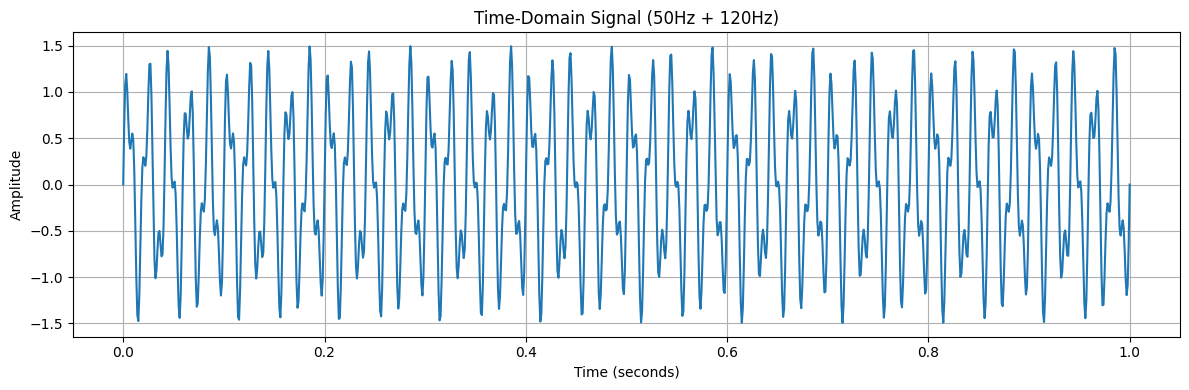

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# # Simulated signal with two sine waves with freq f1 and f2
fs = 1000  # Sampling rate
t = np.linspace(0, 1, fs)
f1=50; f2=120 # frequencies present
# # Composite signal: sin(2*PI*f1*t) + 0.5*sin(2*PI*f2*t)
signal = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)


# === Time-domain plot ===
plt.figure(figsize=(12, 4))
plt.plot(t, signal)
plt.title("Time-Domain Signal (50Hz + 120Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Lets calculate FFT
fft_vals = np.fft.fft(signal)
print(f"first 3 FFT: {fft_vals[:3]}")

freqs = np.fft.fftfreq(len(t), 1/fs)
print(f"first 3 FFT frequencies: {freqs[:3]}")

first 3 FFT: [-7.90478794e-14+0.j          7.47267625e-05-0.02378619j
  2.99216238e-04-0.04762112j]
first 3 FFT frequencies: [0. 1. 2.]


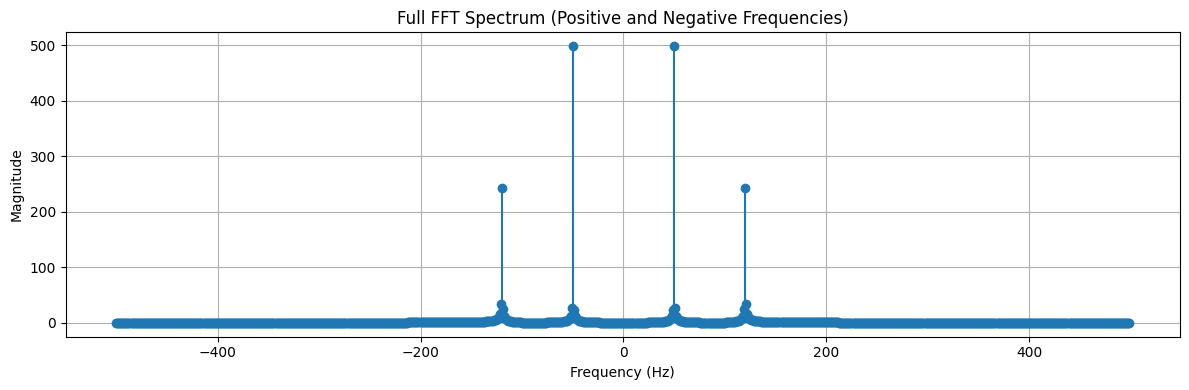

In [17]:
# First we plot full frequency spectrum (both positive and negative)
plt.figure(figsize=(12, 4))
plt.stem(freqs, np.abs(fft_vals), basefmt=" ")
plt.title("Full FFT Spectrum (Positive and Negative Frequencies)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# obser: its very cluttered

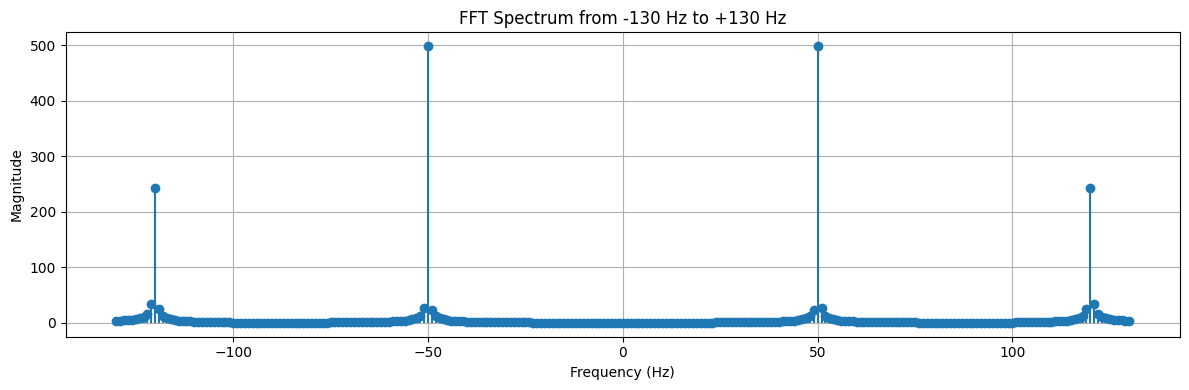

In [22]:
# Now I want to Limit to certain range

mask = (freqs >= -130) & (freqs <= 130)

# Plot
plt.figure(figsize=(12, 4))
plt.stem(freqs[mask], np.abs(fft_vals)[mask], basefmt=" ")
plt.title("FFT Spectrum from -130 Hz to +130 Hz")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

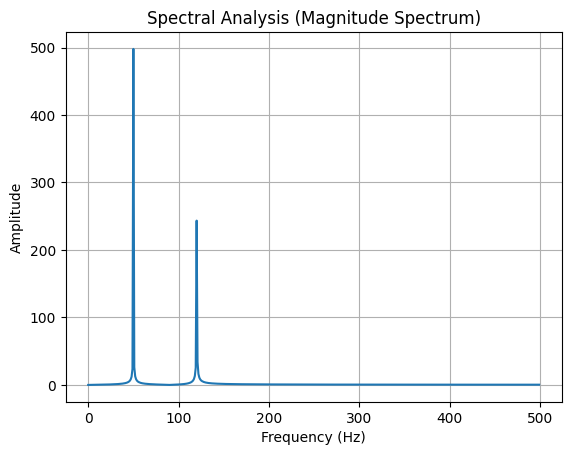

In [21]:
# Now I want to plot just the positive half of the frequency domain

# # === Frequency-domain plot (spectrum) ===

# Only take the positive half for plotting
plt.plot(freqs[:fs//2], np.abs(fft_vals)[:fs//2])

plt.title("Spectral Analysis (Magnitude Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [9]:
# I want to find the magnitude of certain freq

target_freq = 111.4
index = np.argmin(np.abs(freqs - target_freq)) # Find index closest to certain Hz
print(index)
magnitude = np.abs(fft_vals[index])

print(f"Frequency closest to {target_freq} Hz is: {freqs[index]} Hz")
print(f"Magnitude at {freqs[index]} Hz: {magnitude}")

111
Frequency closest to 111.4 Hz is: 111.0 Hz
Magnitude at 111.0 Hz: 2.503867399668348
